In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install mne loguru typer tqdm seaborn tensorflow scikit-learn

In [ ]:
%cd /content/drive/MyDrive/aid-data-analysis-smc-2025-main

/content/drive/MyDrive/aid-data-analysis-smc-2025-main


Loading Epochs and categorizing data...
----------------------------------------
DATA SUMMARY:
Subjects used: ['sub-01', 'sub-02', 'sub-04', 'sub-05', 'sub-07', 'sub-08', 'sub-09', 'sub-10', 'sub-11']
Total Attention_Check Epochs: 189
Total Control Epochs: 1004
----------------------------------------

Calculating Grand Averages and plotting...
Identifying common channels ...
Identifying common channels ...
combining channels using "mean"
combining channels using "mean"


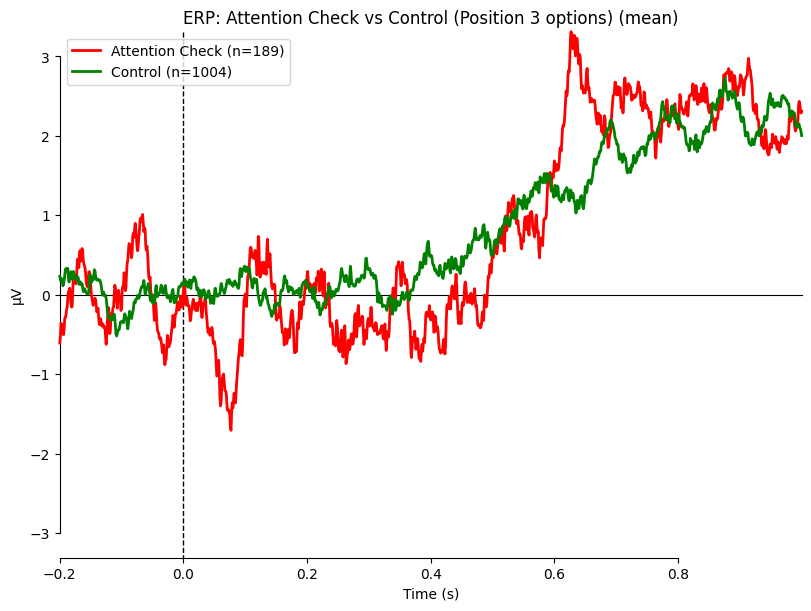


Running Statistical Analysis...

Analyzing Channel: Fz
  -> No significant differences found.

Analyzing Channel: Cz
  -> No significant differences found.

Analyzing Channel: Pz
  -> No significant differences found.


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

mne.use_log_level("warning")

ONSET_DIR = Path("/content/drive/MyDrive/data_set_org/onset_epochs/scenario")

SUBJECTS = [
    "sub-01",
    "sub-02",
    "sub-04",
    "sub-05",
    #"sub-06",
    "sub-07",
    "sub-08",
    "sub-09",
    "sub-10",
    "sub-11",
]

#PICKS   = ['Fz']
PICKS   = ['Cz', 'CPz', 'Pz']
COMBINE = 'mean'

STAT_CHANNELS = ['Fz','Cz', 'Pz']

print("Loading Epochs and categorizing data...")

evokeds_check   = {}
evokeds_control = {}

total_check   = 0
total_control = 0

for subj in SUBJECTS:
    filepath = ONSET_DIR / f"{subj}-onset-epo.fif"
    if not filepath.exists():
        print(f"  {subj}: file not found, skipping")
        continue

    epochs = mne.read_epochs(filepath, preload=True, verbose=False)

    check_epochs   = epochs["Trial_Type == 'Attention_Check' and Word_Position == 3"]
    control_epochs = epochs["Trial_Type == 'Normal' and Word_Position == 3 and Is_Target == False"]

    total_check   += len(check_epochs)
    total_control += len(control_epochs)

    if len(check_epochs) > 0:
        evokeds_check[subj] = check_epochs.average()
    if len(control_epochs) > 0:
        evokeds_control[subj] = control_epochs.average()

    del epochs

print("-" * 40)
print("DATA SUMMARY:")
print(f"Subjects used: {list(evokeds_check.keys())}")
print(f"Total Attention_Check Epochs: {total_check}")
print(f"Total Control Epochs: {total_control}")
print("-" * 40)

# ==============
# Grand Average Plot
# ==============
print("\nCalculating Grand Averages and plotting...")

ga_check   = mne.grand_average(list(evokeds_check.values()))
ga_control = mne.grand_average(list(evokeds_control.values()))

label_check   = f"Attention Check (n={total_check})"
label_control = f"Control (n={total_control})"

dict_evokeds = {
    label_check:   ga_check,
    label_control: ga_control,
}

plot_kwargs = dict(
    combine=COMBINE,
    title="ERP: Attention Check vs Control (Position 3 options)",
    colors={label_check: 'red', label_control: 'green'},
    styles={label_check: {"linewidth": 2}, label_control: {"linewidth": 2}},
    show=False,
)
if PICKS is not None:
    plot_kwargs["picks"] = PICKS

mne.viz.plot_compare_evokeds(dict_evokeds, **plot_kwargs)
plt.show()

# =============
# Cluster-based Permutation + Cohen's d
# =============
print("\nRunning Statistical Analysis...")

common_subjs = sorted(set(evokeds_check.keys()) & set(evokeds_control.keys()))

list_A = [evokeds_check[s]   for s in common_subjs]
list_B = [evokeds_control[s] for s in common_subjs]

times = list_A[0].times
time_mask = (times >= 0.0) & (times <= 0.800)
times_search = times[time_mask]

available_chs = list_A[0].ch_names

for ch in STAT_CHANNELS:
    if ch not in available_chs:
        print(f"\nChannel {ch}: NOT available, skipping")
        continue

    ch_idx = available_chs.index(ch)
    print(f"\nAnalyzing Channel: {ch}")

    X_diff = np.array([
        list_A[i].data[ch_idx, time_mask] - list_B[i].data[ch_idx, time_mask]
        for i in range(len(common_subjs))
    ])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t_obs, clusters, cluster_p_values, H0 = \
            mne.stats.permutation_cluster_1samp_test(
                X_diff, n_permutations=1000, seed=42, tail=0, verbose=False
            )

    sig_found = False
    if len(clusters) > 0:
        for i, cluster in enumerate(clusters):
            p_val = cluster_p_values[i]
            if p_val < 0.05:
                time_indices = cluster[0]
                idx_start = time_indices.start if isinstance(time_indices, slice) else time_indices[0]
                idx_stop  = time_indices.stop - 1 if isinstance(time_indices, slice) else time_indices[-1]

                t_start = times_search[idx_start] * 1000
                t_end   = times_search[idx_stop] * 1000

                cluster_data = X_diff[:, idx_start:idx_stop+1].mean(axis=1)
                mean_diff = cluster_data.mean()
                std_diff  = cluster_data.std(ddof=1)
                cohens_d  = mean_diff / std_diff if std_diff > 0 else 0.0

                direction = "CHECK > CONTROL" if mean_diff > 0 else "CONTROL > CHECK"

                print(f"  [***] CLUSTER: {t_start:.1f} to {t_end:.1f} ms | p={p_val:.4f} | {direction} | Cohen's d={cohens_d:.3f}")
                sig_found = True

    if not sig_found:
        print("  -> No significant differences found.")

#Individuals Plots

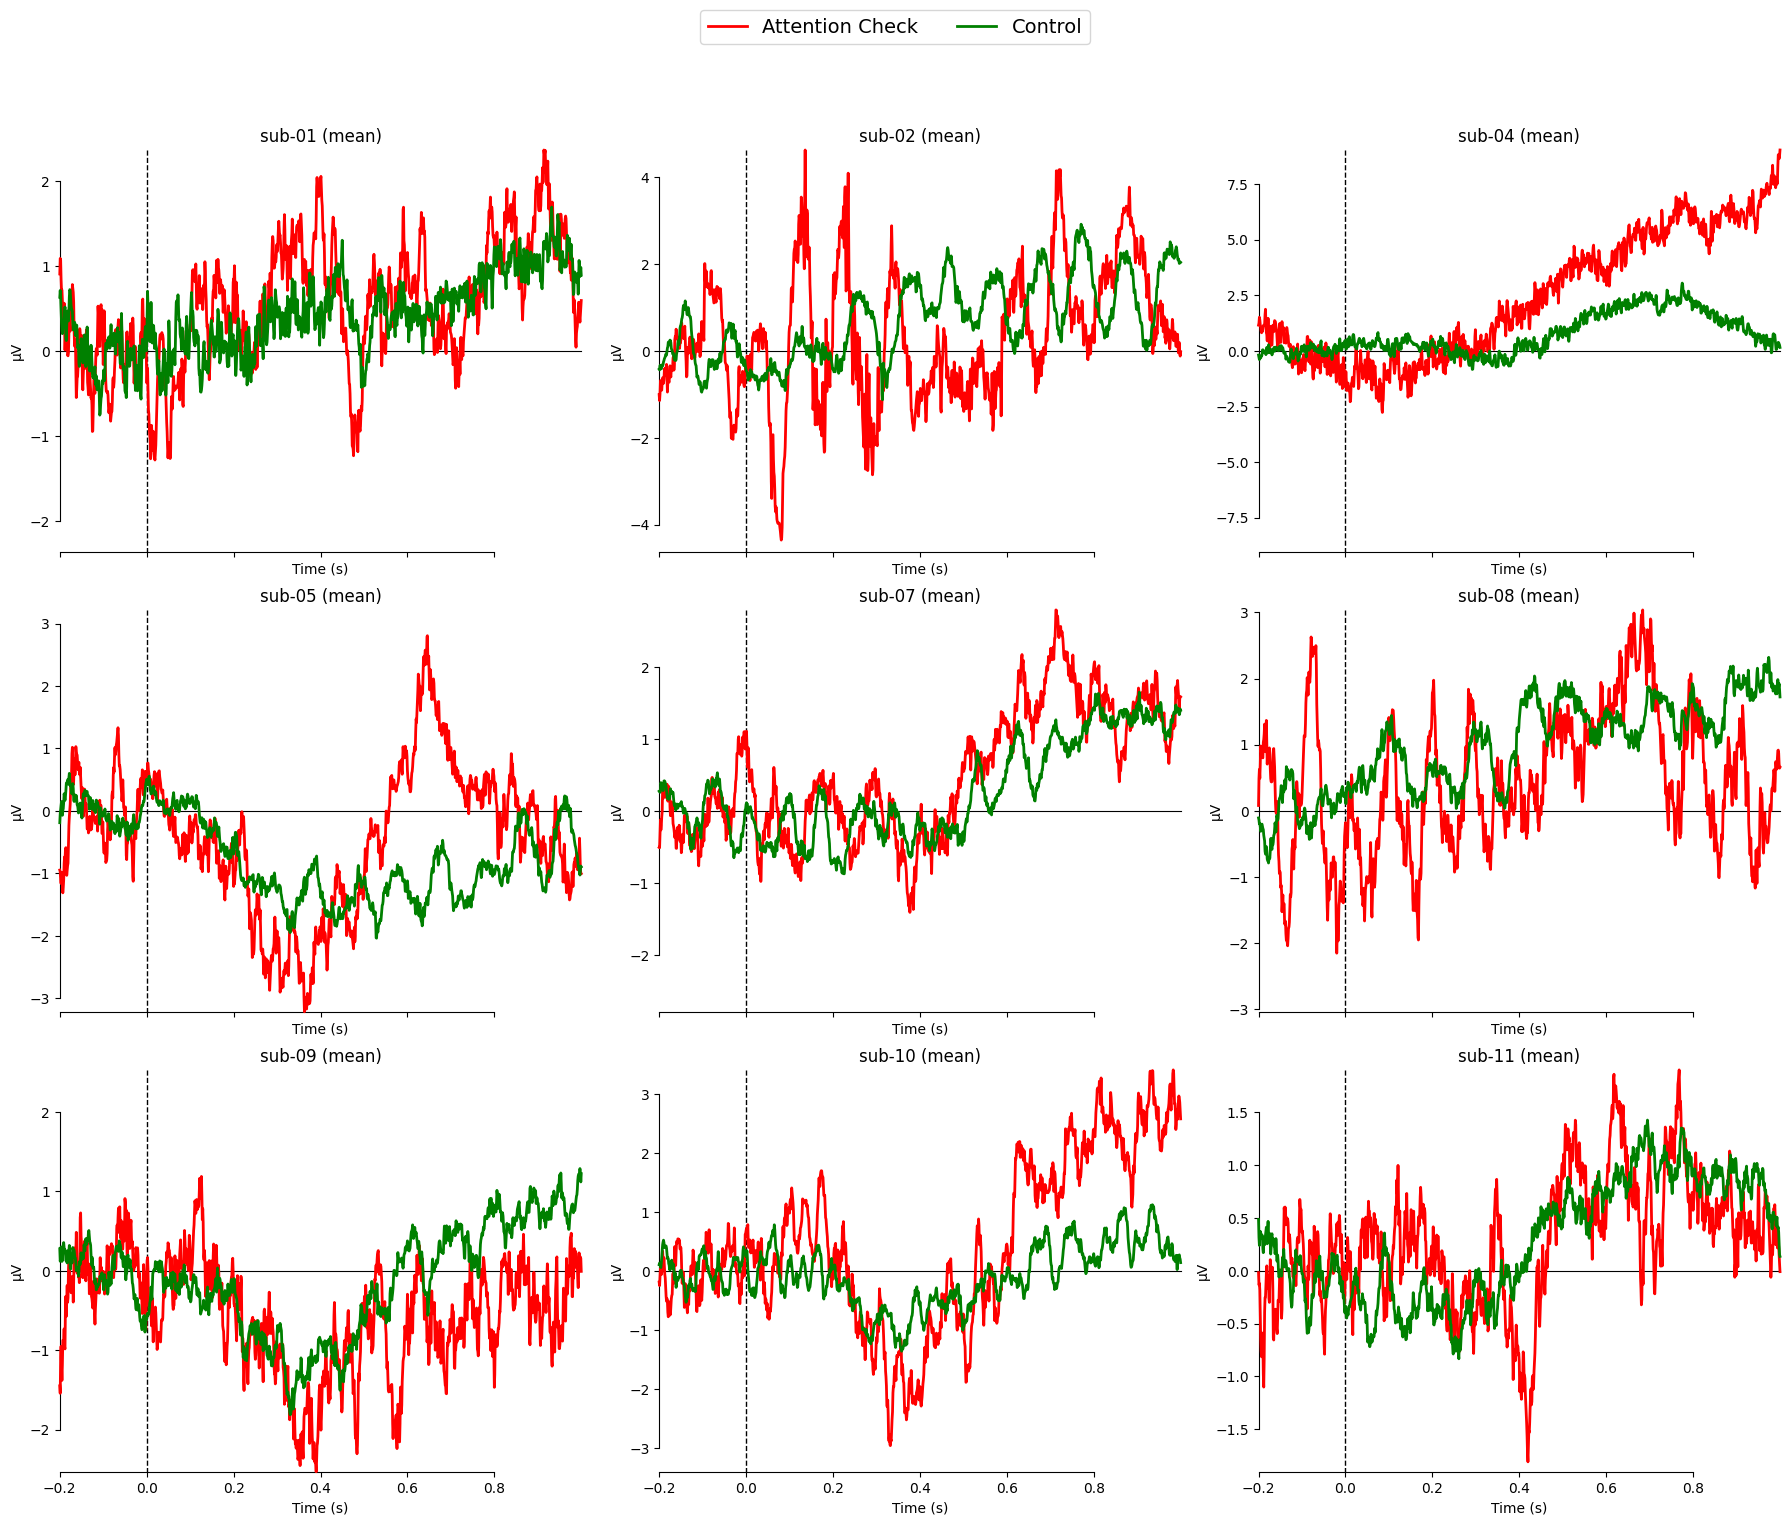

In [ ]:
import mne
import matplotlib.pyplot as plt
from pathlib import Path
import math
import os
from contextlib import redirect_stdout

mne.set_log_level("ERROR")

subjects = sorted(list(set(evokeds_check.keys()) & set(evokeds_control.keys())))
n_subs = len(subjects)
cols = 3
rows = math.ceil(n_subs / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharex=True, sharey=False)
axes = axes.flatten()

for i, subj in enumerate(subjects):
    ev_dict_subj = {
        "Attention Check": evokeds_check[subj],
        "Control": evokeds_control[subj]
    }

    with open(os.devnull, 'w') as f, redirect_stdout(f):
        mne.viz.plot_compare_evokeds(
            ev_dict_subj,
            picks=['Cz', 'Fz', 'Pz'],
            combine='mean',
            axes=axes[i],
            title=subj,
            colors={"Attention Check": 'red', "Control": 'green'},
            styles={"Attention Check": {"linewidth": 2},
                    "Control": {"linewidth": 2}},
            show=False,
            legend=False
        )

for j in range(n_subs, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

Loading...
Plotting topographies...


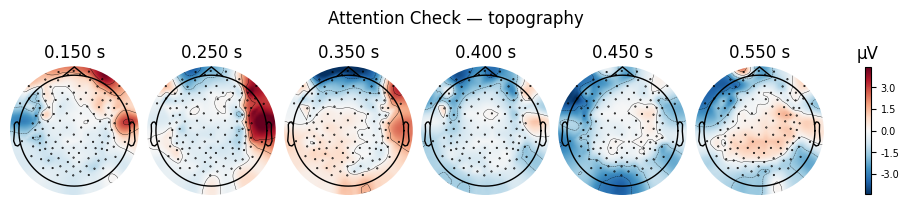

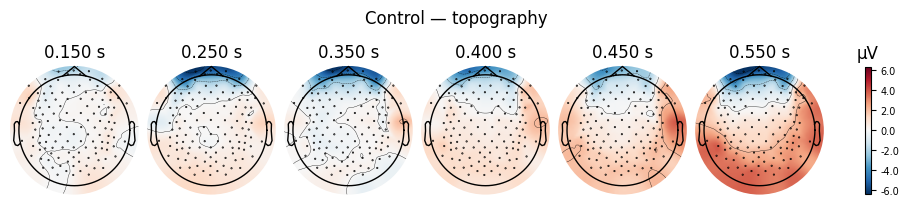

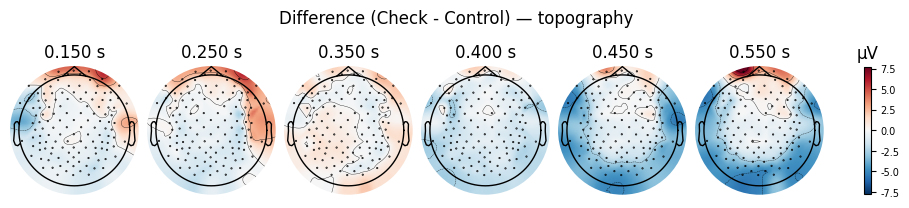

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

mne.use_log_level("warning")

ONSET_DIR = Path("/content/drive/MyDrive/data_set_org/onset_epochs/scenario")

SUBJECTS = [
    "sub-01",
    "sub-02",
    "sub-04",
    "sub-05",
    #"sub-06",
    "sub-07",
    "sub-08",
    "sub-09",
    "sub-10",
    "sub-11",
]

evokeds_check   = {}
evokeds_control = {}

print("Loading...")

for subj in SUBJECTS:
    filepath = ONSET_DIR / f"{subj}-onset-epo.fif"
    if not filepath.exists():
        continue

    epochs = mne.read_epochs(filepath, preload=True, verbose=False)

    check_ep   = epochs["Trial_Type == 'Attention_Check' and Word_Position == 3"]
    control_ep = epochs["Trial_Type == 'Normal' and Word_Position == 3 and Is_Target == False"]

    if len(check_ep) > 0:
        evokeds_check[subj] = check_ep.average()
    if len(control_ep) > 0:
        evokeds_control[subj] = control_ep.average()

    del epochs

common_subjs = sorted(set(evokeds_check.keys()) & set(evokeds_control.keys()))

ga_check   = mne.grand_average([evokeds_check[s]   for s in common_subjs])
ga_control = mne.grand_average([evokeds_control[s] for s in common_subjs])

ga_diff = mne.combine_evoked([ga_check, ga_control], weights=[1, -1])

times_to_plot = [0.150, 0.250, 0.350, 0.400, 0.450, 0.550]

print("Plotting topographies...")

# ── Attention Check ──
fig1 = ga_check.plot_topomap(times=times_to_plot, ch_type='eeg',
                             show=False, colorbar=True)
fig1.suptitle("Attention Check — topography", y=1.05)
plt.show()

# ── Control ──
fig2 = ga_control.plot_topomap(times=times_to_plot, ch_type='eeg',
                               show=False, colorbar=True)
fig2.suptitle("Control — topography", y=1.05)
plt.show()

# ── Difference (Check - Control) ──
fig3 = ga_diff.plot_topomap(times=times_to_plot, ch_type='eeg',
                            show=False, colorbar=True)
fig3.suptitle("Difference (Check - Control) — topography", y=1.05)
plt.show()

Loading Epochs and categorizing data...
----------------------------------------
DATA SUMMARY:
Subjects used: ['sub-01', 'sub-02', 'sub-04', 'sub-05', 'sub-07', 'sub-08', 'sub-09', 'sub-10', 'sub-11']
Total Attention_Check Epochs: 189
Total Control Epochs: 1004
----------------------------------------

Calculating Grand Averages and plotting...


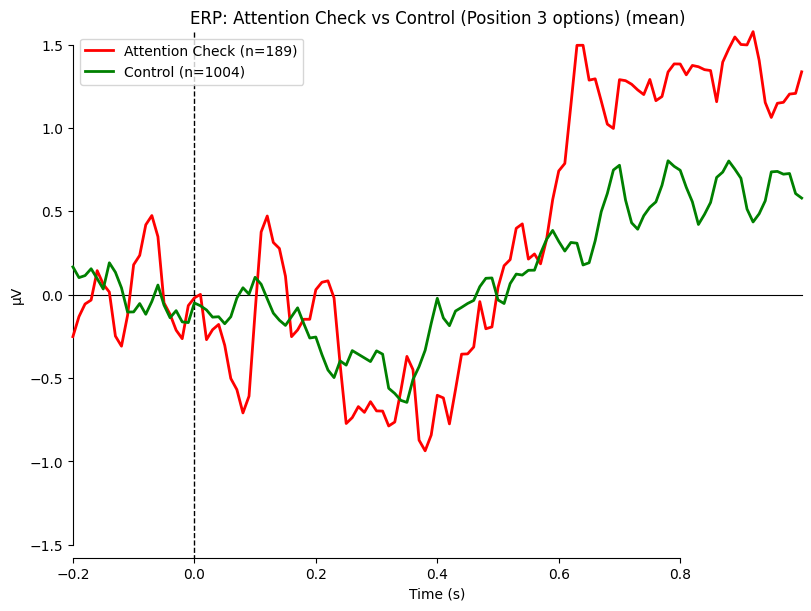


Running Statistical Analysis...

Analyzing Channel: Cz
  -> No significant differences found.

Analyzing Channel: Fz
  -> No significant differences found.

Analyzing Channel: Pz
  -> No significant differences found.


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

mne.use_log_level("warning")

ONSET_DIR = Path("/content/drive/MyDrive/data_set_org/onset_epochs/scenario_ica")

SUBJECTS = [
    "sub-01",
    "sub-02",
    "sub-04",
    "sub-05",
    #"sub-06",
    "sub-07",
    "sub-08",
    "sub-09",
    "sub-10",
    "sub-11",
]

PICKS   = ['Cz', 'Fz', 'Pz']
COMBINE = 'mean'

STAT_CHANNELS = ['Cz', 'Fz', 'Pz']

print("Loading Epochs and categorizing data...")

evokeds_check   = {}
evokeds_control = {}

total_check   = 0
total_control = 0

for subj in SUBJECTS:
    filepath = ONSET_DIR / f"{subj}-onset-epo.fif"
    if not filepath.exists():
        print(f"  {subj}: file not found, skipping")
        continue

    epochs = mne.read_epochs(filepath, preload=True, verbose=False)

    check_epochs   = epochs["Trial_Type == 'Attention_Check' and Word_Position == 3"]
    control_epochs = epochs["Trial_Type == 'Normal' and Word_Position == 3 and Is_Target == False"]

    total_check   += len(check_epochs)
    total_control += len(control_epochs)

    if len(check_epochs) > 0:
        evokeds_check[subj] = check_epochs.average()
    if len(control_epochs) > 0:
        evokeds_control[subj] = control_epochs.average()

    del epochs

print("-" * 40)
print("DATA SUMMARY:")
print(f"Subjects used: {list(evokeds_check.keys())}")
print(f"Total Attention_Check Epochs: {total_check}")
print(f"Total Control Epochs: {total_control}")
print("-" * 40)

# ===========
# Grand Average Plot
# ===========
print("\nCalculating Grand Averages and plotting...")

ga_check   = mne.grand_average(list(evokeds_check.values()))
ga_control = mne.grand_average(list(evokeds_control.values()))

label_check   = f"Attention Check (n={total_check})"
label_control = f"Control (n={total_control})"

dict_evokeds = {
    label_check:   ga_check,
    label_control: ga_control,
}

plot_kwargs = dict(
    combine=COMBINE,
    title="ERP: Attention Check vs Control (Position 3 options)",
    colors={label_check: 'red', label_control: 'green'},
    styles={label_check: {"linewidth": 2}, label_control: {"linewidth": 2}},
    show=False,
)
if PICKS is not None:
    plot_kwargs["picks"] = PICKS

mne.viz.plot_compare_evokeds(dict_evokeds, **plot_kwargs)
plt.show()

# ==
# Cluster-based Permutation + Cohen's d
# ==
print("\nRunning Statistical Analysis...")

common_subjs = sorted(set(evokeds_check.keys()) & set(evokeds_control.keys()))

list_A = [evokeds_check[s]   for s in common_subjs]
list_B = [evokeds_control[s] for s in common_subjs]

times = list_A[0].times
time_mask = (times >= 0.0) & (times <= 0.800)
times_search = times[time_mask]

available_chs = list_A[0].ch_names

for ch in STAT_CHANNELS:
    if ch not in available_chs:
        print(f"\nChannel {ch}: NOT available, skipping")
        continue

    ch_idx = available_chs.index(ch)
    print(f"\nAnalyzing Channel: {ch}")

    X_diff = np.array([
        list_A[i].data[ch_idx, time_mask] - list_B[i].data[ch_idx, time_mask]
        for i in range(len(common_subjs))
    ])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t_obs, clusters, cluster_p_values, H0 = \
            mne.stats.permutation_cluster_1samp_test(
                X_diff, n_permutations=1000, seed=42, tail=0, verbose=False
            )

    sig_found = False
    if len(clusters) > 0:
        for i, cluster in enumerate(clusters):
            p_val = cluster_p_values[i]
            if p_val < 0.05:
                time_indices = cluster[0]
                idx_start = time_indices.start if isinstance(time_indices, slice) else time_indices[0]
                idx_stop  = time_indices.stop - 1 if isinstance(time_indices, slice) else time_indices[-1]

                t_start = times_search[idx_start] * 1000
                t_end   = times_search[idx_stop] * 1000

                cluster_data = X_diff[:, idx_start:idx_stop+1].mean(axis=1)
                mean_diff = cluster_data.mean()
                std_diff  = cluster_data.std(ddof=1)
                cohens_d  = mean_diff / std_diff if std_diff > 0 else 0.0

                direction = "CHECK > CONTROL" if mean_diff > 0 else "CONTROL > CHECK"

                print(f"  [***] CLUSTER: {t_start:.1f} to {t_end:.1f} ms | p={p_val:.4f} | {direction} | Cohen's d={cohens_d:.3f}")
                sig_found = True

    if not sig_found:
        print("  -> No significant differences found.")

Loading...
Plotting topographies...


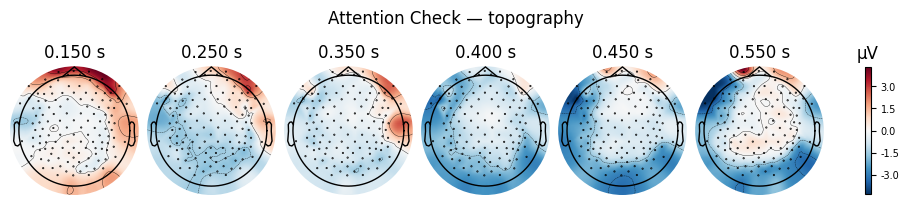

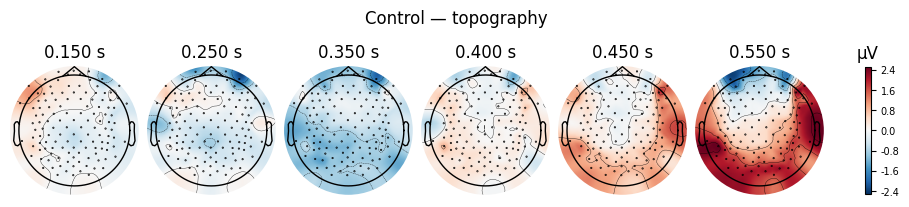

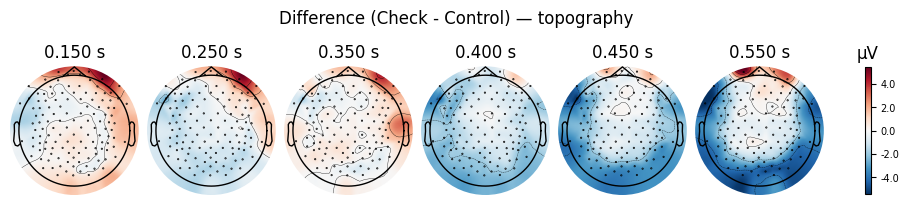

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

mne.use_log_level("warning")

ONSET_DIR = Path("/content/drive/MyDrive/data_set_org/onset_epochs/scenario_ica")

SUBJECTS = [
    "sub-01",
    "sub-02",
    "sub-04",
    "sub-05",
    #"sub-06",
    "sub-07",
    "sub-08",
    "sub-09",
    "sub-10",
    "sub-11",
]

evokeds_check   = {}
evokeds_control = {}

print("Loading...")

for subj in SUBJECTS:
    filepath = ONSET_DIR / f"{subj}-onset-epo.fif"
    if not filepath.exists():
        continue

    epochs = mne.read_epochs(filepath, preload=True, verbose=False)

    check_ep   = epochs["Trial_Type == 'Attention_Check' and Word_Position == 3"]
    control_ep = epochs["Trial_Type == 'Normal' and Word_Position == 3 and Is_Target == False"]

    if len(check_ep) > 0:
        evokeds_check[subj] = check_ep.average()
    if len(control_ep) > 0:
        evokeds_control[subj] = control_ep.average()

    del epochs

common_subjs = sorted(set(evokeds_check.keys()) & set(evokeds_control.keys()))

ga_check   = mne.grand_average([evokeds_check[s]   for s in common_subjs])
ga_control = mne.grand_average([evokeds_control[s] for s in common_subjs])

ga_diff = mne.combine_evoked([ga_check, ga_control], weights=[1, -1])

times_to_plot = [0.150, 0.250, 0.350, 0.400, 0.450, 0.550]

print("Plotting topographies...")

# ── Attention Check ──
fig1 = ga_check.plot_topomap(times=times_to_plot, ch_type='eeg',
                             show=False, colorbar=True)
fig1.suptitle("Attention Check — topography", y=1.05)
plt.show()

# ── Control
fig2 = ga_control.plot_topomap(times=times_to_plot, ch_type='eeg',
                               show=False, colorbar=True)
fig2.suptitle("Control — topography", y=1.05)
plt.show()

# ── Difference (Check - Control)
fig3 = ga_diff.plot_topomap(times=times_to_plot, ch_type='eeg',
                            show=False, colorbar=True)
fig3.suptitle("Difference (Check - Control) — topography", y=1.05)
plt.show()

#Offset

Loading Epochs and categorizing data...
----------------------------------------
DATA SUMMARY:
Subjects used: ['sub-01', 'sub-02', 'sub-04', 'sub-05', 'sub-07', 'sub-08', 'sub-09', 'sub-10', 'sub-11']
Total Attention_Check Epochs: 189
Total Control Epochs: 1004
----------------------------------------

Calculating Grand Averages and plotting...
Identifying common channels ...
Identifying common channels ...
combining channels using "mean"
combining channels using "mean"


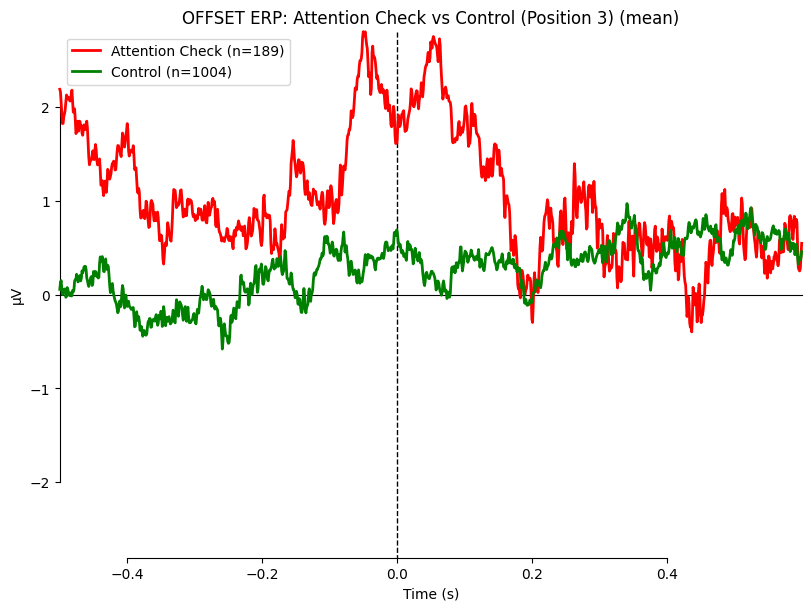


Running Statistical Analysis...

Analyzing Channel: Cz
  -> No significant differences found.

Analyzing Channel: CPz
  [***] CLUSTER: 2.0 to 60.0 ms | p=0.0352 | CHECK > CONTROL | Cohen's d=1.341

Analyzing Channel: Pz
  -> No significant differences found.

Analyzing Channel: Fz
  -> No significant differences found.


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

mne.use_log_level("warning")

OFFSET_DIR = Path("/content/drive/MyDrive/data_set_org/offset_epochs/scenario")

SUBJECTS = [
    "sub-01",
    "sub-02",
    "sub-04",
    "sub-05",
    #"sub-06",
    "sub-07",
    "sub-08",
    "sub-09",
    "sub-10",
    "sub-11",
]

#PICKS   = ['CPz']
PICKS   = ['Cz', 'CPz', 'Pz']
COMBINE = 'mean'

STAT_CHANNELS = ['Cz', 'CPz', 'Pz', 'Fz']

print("Loading Epochs and categorizing data...")

evokeds_check   = {}
evokeds_control = {}

total_check   = 0
total_control = 0

for subj in SUBJECTS:
    filepath = OFFSET_DIR / f"{subj}-offset-epo.fif"
    if not filepath.exists():
        print(f"  {subj}: file not found, skipping")
        continue

    epochs = mne.read_epochs(filepath, preload=True, verbose=False)

    check_epochs   = epochs["Trial_Type == 'Attention_Check' and Word_Position == 3"]
    control_epochs = epochs["Trial_Type == 'Normal' and Word_Position == 3 and Is_Target == False"]

    total_check   += len(check_epochs)
    total_control += len(control_epochs)

    if len(check_epochs) > 0:
        evokeds_check[subj] = check_epochs.average()
    if len(control_epochs) > 0:
        evokeds_control[subj] = control_epochs.average()

    del epochs

print("-" * 40)
print("DATA SUMMARY:")
print(f"Subjects used: {list(evokeds_check.keys())}")
print(f"Total Attention_Check Epochs: {total_check}")
print(f"Total Control Epochs: {total_control}")
print("-" * 40)

# ==============
# Grand Average Plot
# ==============
print("\nCalculating Grand Averages and plotting...")

ga_check   = mne.grand_average(list(evokeds_check.values()))
ga_control = mne.grand_average(list(evokeds_control.values()))

label_check   = f"Attention Check (n={total_check})"
label_control = f"Control (n={total_control})"

dict_evokeds = {
    label_check:   ga_check,
    label_control: ga_control,
}

plot_kwargs = dict(
    combine=COMBINE,
    title="OFFSET ERP: Attention Check vs Control (Position 3)",
    colors={label_check: 'red', label_control: 'green'},
    styles={label_check: {"linewidth": 2}, label_control: {"linewidth": 2}},
    show=False,
)
if PICKS is not None:
    plot_kwargs["picks"] = PICKS

mne.viz.plot_compare_evokeds(dict_evokeds, **plot_kwargs)
plt.show()

# =============
# Cluster-based Permutation + Cohen's d
# =============
print("\nRunning Statistical Analysis...")

common_subjs = sorted(set(evokeds_check.keys()) & set(evokeds_control.keys()))

list_A = [evokeds_check[s]   for s in common_subjs]
list_B = [evokeds_control[s] for s in common_subjs]

times = list_A[0].times
time_mask = (times >= -0.1) & (times <= 0.500)
times_search = times[time_mask]

available_chs = list_A[0].ch_names

for ch in STAT_CHANNELS:
    if ch not in available_chs:
        print(f"\nChannel {ch}: NOT available, skipping")
        continue

    ch_idx = available_chs.index(ch)
    print(f"\nAnalyzing Channel: {ch}")

    X_diff = np.array([
        list_A[i].data[ch_idx, time_mask] - list_B[i].data[ch_idx, time_mask]
        for i in range(len(common_subjs))
    ])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t_obs, clusters, cluster_p_values, H0 = \
            mne.stats.permutation_cluster_1samp_test(
                X_diff, n_permutations=1000, seed=42, tail=0, verbose=False
            )

    sig_found = False
    if len(clusters) > 0:
        for i, cluster in enumerate(clusters):
            p_val = cluster_p_values[i]
            if p_val < 0.05:
                time_indices = cluster[0]
                idx_start = time_indices.start if isinstance(time_indices, slice) else time_indices[0]
                idx_stop  = time_indices.stop - 1 if isinstance(time_indices, slice) else time_indices[-1]

                t_start = times_search[idx_start] * 1000
                t_end   = times_search[idx_stop] * 1000

                cluster_data = X_diff[:, idx_start:idx_stop+1].mean(axis=1)
                mean_diff = cluster_data.mean()
                std_diff  = cluster_data.std(ddof=1)
                cohens_d  = mean_diff / std_diff if std_diff > 0 else 0.0

                direction = "CHECK > CONTROL" if mean_diff > 0 else "CONTROL > CHECK"

                print(f"  [***] CLUSTER: {t_start:.1f} to {t_end:.1f} ms | p={p_val:.4f} | {direction} | Cohen's d={cohens_d:.3f}")
                sig_found = True

    if not sig_found:
        print("  -> No significant differences found.")

#Variation of Onset

Loading Epochs with subsampling...
----------------------------------------
DATA SUMMARY:
Subjects used: ['sub-01', 'sub-02', 'sub-04', 'sub-05', 'sub-07', 'sub-08', 'sub-09', 'sub-10', 'sub-11']
Total Attention_Check Epochs: 189
Control subsampled to match check (5 repeats averaged)
----------------------------------------

Calculating Grand Averages and plotting...
Identifying common channels ...
Identifying common channels ...
combining channels using "mean"
combining channels using "mean"


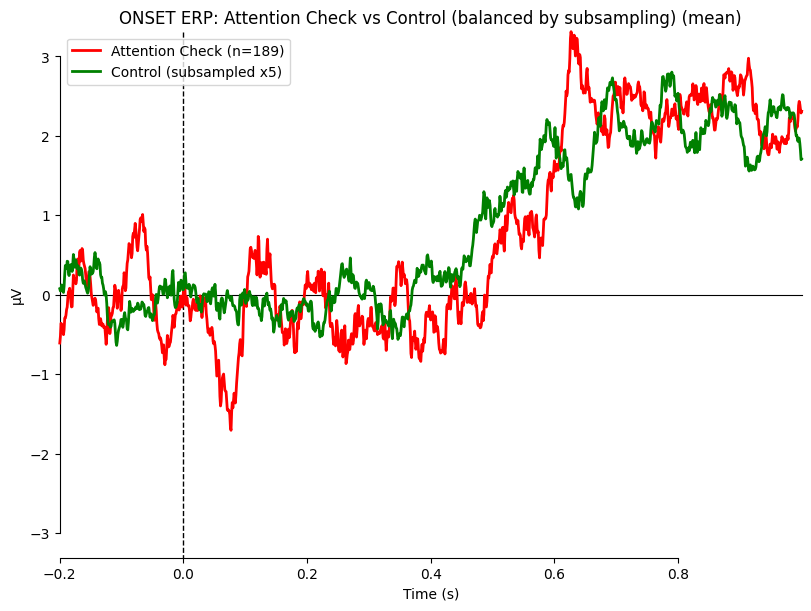


Running Statistical Analysis...

Analyzing Channel: Fz
  -> No significant differences found.

Analyzing Channel: Cz
  -> No significant differences found.

Analyzing Channel: CPz
  -> No significant differences found.

Analyzing Channel: Pz
  -> No significant differences found.


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

mne.use_log_level("warning")

ONSET_DIR = Path("/content/drive/MyDrive/data_set_org/onset_epochs/scenario")

SUBJECTS = [
    "sub-01",
    "sub-02",
    "sub-04",
    "sub-05",
    #"sub-06",
    "sub-07",
    "sub-08",
    "sub-09",
    "sub-10",
    "sub-11",
]

PICKS   = ['Cz', 'CPz', 'Pz']
COMBINE = 'mean'

STAT_CHANNELS = ['Fz','Cz', 'CPz', 'Pz']

N_REPEATS = 5
RANDOM_SEED = 42

print("Loading Epochs with subsampling...")


evokeds_check   = {}
evokeds_control = {}

total_check   = 0
total_control_sub = 0

rng = np.random.default_rng(RANDOM_SEED)

for subj in SUBJECTS:
    filepath = ONSET_DIR / f"{subj}-onset-epo.fif"
    if not filepath.exists():
        print(f"  {subj}: file not found, skipping")
        continue

    epochs = mne.read_epochs(filepath, preload=True, verbose=False)

    check_epochs   = epochs["Trial_Type == 'Attention_Check' and Word_Position == 3"]
    control_epochs = epochs["Trial_Type == 'Normal' and Word_Position == 3 and Is_Target == False"]

    n_check = len(check_epochs)

    if n_check == 0 or len(control_epochs) == 0:
        del epochs
        continue

    total_check += n_check

    # check evoked
    evokeds_check[subj] = check_epochs.average()

    control_data = control_epochs.get_data()
    n_control = len(control_epochs)

    subsample_evokeds = []
    for rep in range(N_REPEATS):
        if n_control >= n_check:
            idx = rng.choice(n_control, size=n_check, replace=False)
        else:
            idx = rng.choice(n_control, size=n_check, replace=True)
        sub_data = control_data[idx].mean(axis=0)
        subsample_evokeds.append(sub_data)

    mean_control_data = np.mean(subsample_evokeds, axis=0)
    evokeds_control[subj] = mne.EvokedArray(mean_control_data, control_epochs.info,
                                            tmin=control_epochs.tmin)
    total_control_sub += n_check

    del epochs

print("-" * 40)
print("DATA SUMMARY:")
print(f"Subjects used: {list(evokeds_check.keys())}")
print(f"Total Attention_Check Epochs: {total_check}")
print(f"Control subsampled to match check ({N_REPEATS} repeats averaged)")
print("-" * 40)

# ==============
# Grand Average Plot
# ==============
print("\nCalculating Grand Averages and plotting...")

ga_check   = mne.grand_average(list(evokeds_check.values()))
ga_control = mne.grand_average(list(evokeds_control.values()))

label_check   = f"Attention Check (n={total_check})"
label_control = f"Control (subsampled x{N_REPEATS})"

dict_evokeds = {
    label_check:   ga_check,
    label_control: ga_control,
}

plot_kwargs = dict(
    combine=COMBINE,
    title="ONSET ERP: Attention Check vs Control (balanced by subsampling)",
    colors={label_check: 'red', label_control: 'green'},
    styles={label_check: {"linewidth": 2}, label_control: {"linewidth": 2}},
    show=False,
)
if PICKS is not None:
    plot_kwargs["picks"] = PICKS

mne.viz.plot_compare_evokeds(dict_evokeds, **plot_kwargs)
plt.show()

# =============
# Cluster-based Permutation + Cohen's d
# =============
print("\nRunning Statistical Analysis...")

common_subjs = sorted(set(evokeds_check.keys()) & set(evokeds_control.keys()))

list_A = [evokeds_check[s]   for s in common_subjs]
list_B = [evokeds_control[s] for s in common_subjs]

times = list_A[0].times
time_mask = (times >= 0.0) & (times <= 0.800)
times_search = times[time_mask]

available_chs = list_A[0].ch_names

for ch in STAT_CHANNELS:
    if ch not in available_chs:
        print(f"\nChannel {ch}: NOT available, skipping")
        continue

    ch_idx = available_chs.index(ch)
    print(f"\nAnalyzing Channel: {ch}")

    X_diff = np.array([
        list_A[i].data[ch_idx, time_mask] - list_B[i].data[ch_idx, time_mask]
        for i in range(len(common_subjs))
    ])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t_obs, clusters, cluster_p_values, H0 = \
            mne.stats.permutation_cluster_1samp_test(
                X_diff, n_permutations=1000, seed=42, tail=0, verbose=False
            )

    sig_found = False
    if len(clusters) > 0:
        for i, cluster in enumerate(clusters):
            p_val = cluster_p_values[i]
            if p_val < 0.05:
                time_indices = cluster[0]
                idx_start = time_indices.start if isinstance(time_indices, slice) else time_indices[0]
                idx_stop  = time_indices.stop - 1 if isinstance(time_indices, slice) else time_indices[-1]

                t_start = times_search[idx_start] * 1000
                t_end   = times_search[idx_stop] * 1000

                cluster_data = X_diff[:, idx_start:idx_stop+1].mean(axis=1)
                mean_diff = cluster_data.mean()
                std_diff  = cluster_data.std(ddof=1)
                cohens_d  = mean_diff / std_diff if std_diff > 0 else 0.0

                direction = "CHECK > CONTROL" if mean_diff > 0 else "CONTROL > CHECK"

                print(f"  [***] CLUSTER: {t_start:.1f} to {t_end:.1f} ms | p={p_val:.4f} | {direction} | Cohen's d={cohens_d:.3f}")
                sig_found = True

    if not sig_found:
        print("  -> No significant differences found.")

#EEGNet

In [ ]:
import mne
import numpy as np
from pathlib import Path
import gc

mne.use_log_level("warning")

ONSET_DIR = Path("/content/drive/MyDrive/data_set_org/onset_epochs/scenario")

SUBJECTS = [
    "sub-01",
    "sub-02",
    "sub-04",
    "sub-05",
    # "sub-06",
    "sub-07",
    "sub-08",
    "sub-09",
    "sub-10",
    "sub-11",
]

data_list, target_list, subject_list = [], [], []

for subj in SUBJECTS:
    input_file = ONSET_DIR / f"{subj}-onset-epo.fif"
    epochs = mne.read_epochs(input_file, preload=True, verbose=False)
    epochs.resample(128, verbose=False)

    check_epochs   = epochs["Trial_Type == 'Attention_Check' and Word_Position == 3"]
    control_epochs = epochs["Trial_Type == 'Normal' and Word_Position == 3 and Is_Target == False"]

    for epoch_set, target in [(check_epochs, 1), (control_epochs, 0)]:
        d = epoch_set.get_data().astype(np.float32)
        data_list.append(d)
        target_list.append(np.full(len(d), target))
        subject_list.append(np.full(len(d), subj))

    print(f"{subj}: check={len(check_epochs)}, control={len(control_epochs)}")

    del epochs, check_epochs, control_epochs
    gc.collect()

data = np.concatenate(data_list, axis=0)
targets = np.concatenate(target_list, axis=0)
subject_ids = np.concatenate(subject_list, axis=0)

del data_list, target_list, subject_list
gc.collect()

n_check   = np.sum(targets == 1)
n_control = np.sum(targets == 0)
zero_rule = max(n_check, n_control) / (n_check + n_control)

print()
print(f"data shape: {data.shape}")
print(f"Attention Check (1): {n_check}")
print(f"Control         (0): {n_control}")
print(f"Zero-rule baseline:  {zero_rule:.4f}")
print(f"subjects: {len(np.unique(subject_ids))}")

sub-01: check=21, control=115
sub-02: check=21, control=112
sub-04: check=21, control=102
sub-05: check=21, control=109
sub-07: check=21, control=115
sub-08: check=21, control=110
sub-09: check=21, control=113
sub-10: check=21, control=112
sub-11: check=21, control=116

data shape: (1193, 126, 154)
Attention Check (1): 189
Control         (0): 1004
Zero-rule baseline:  0.8416
subjects: 9


In [ ]:
import sys
import numpy as np
import pandas as pd
import mne
import gc
from sklearn import metrics
from sklearn.model_selection import LeaveOneGroupOut
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

sys.path.append("/content/drive/MyDrive/aid-data-analysis-smc-2025-main/aid_data_analysis/external")
from EEGModels import EEGNet

N_EPOCHS = 50


def eegnet_reshape(data):
    return data.reshape((data.shape[0], data.shape[1], data.shape[2], 1))


labels_onehot = np.stack([-targets + 1, targets], axis=1)

logo = LeaveOneGroupOut()
splits = logo.split(data, targets, subject_ids)
n_splits = len(np.unique(subject_ids))

accuracies = []
f1_scores = []
prediction_rows = []

for i, split in enumerate(splits):
    data_train = data[split[0]]
    labels_train = labels_onehot[split[0]]

    data_test = data[split[1]]
    labels_test = labels_onehot[split[1]]
    subject_ids_test = subject_ids[split[1]]

    held_out = np.unique(subject_ids_test)[0]
    print(f"\n--- Split {i + 1}/{n_splits} | held out: {held_out} ---")

    scaler = mne.decoding.Scaler(scalings="median")
    data_train_scaled = scaler.fit_transform(data_train)
    data_test_scaled = scaler.transform(data_test)

    data_train_scaled_shaped = eegnet_reshape(data_train_scaled)
    data_test_scaled_shaped = eegnet_reshape(data_test_scaled)

    model = EEGNet(2, 126, data_train_scaled_shaped.shape[-2])
    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    model.fit(data_train_scaled_shaped, labels_train, epochs=N_EPOCHS, batch_size=32, verbose=0)

    argmax_labels = np.argmax(labels_test, axis=1)
    argmax_predictions = np.argmax(model.predict(data_test_scaled_shaped, verbose=0), axis=1)

    accuracies.append(metrics.accuracy_score(argmax_labels, argmax_predictions))
    f1_scores.append(metrics.f1_score(argmax_labels, argmax_predictions, average='weighted'))

    print(f"{held_out} -> Accuracy: {accuracies[-1]:.4f} | F1: {f1_scores[-1]:.4f}")

    prediction_rows.append(pd.DataFrame({
        "prediction": argmax_predictions,
        "label": argmax_labels,
        "subject": subject_ids_test
    }))

    del model, data_train, data_test, data_train_scaled, data_test_scaled
    del data_train_scaled_shaped, data_test_scaled_shaped
    K.clear_session()
    gc.collect()

prediction_df = pd.concat(prediction_rows, ignore_index=True)

print()
print(f"Mean Accuracy: {np.mean(accuracies):.4f} +/- {np.std(accuracies):.4f}")
print(f"Mean F1 Score: {np.mean(f1_scores):.4f} +/- {np.std(f1_scores):.4f}")


--- Split 1/9 | held out: sub-01 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


sub-01 -> Accuracy: 0.8088 | F1: 0.7665

--- Split 2/9 | held out: sub-02 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


sub-02 -> Accuracy: 0.8346 | F1: 0.7662

--- Split 3/9 | held out: sub-04 ---


...

sub-09 -> Accuracy: 0.8433 | F1: 0.7716

--- Split 8/9 | held out: sub-10 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


sub-10 -> Accuracy: 0.8571 | F1: 0.8037

--- Split 9/9 | held out: sub-11 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


sub-11 -> Accuracy: 0.8467 | F1: 0.8088

Mean Accuracy: 0.8338 +/- 0.0164
Mean F1 Score: 0.7869 +/- 0.0196


Baseline accuracy:  0.8340
Baseline F1 score:  0.7917
Zero-rule baseline: 0.8416




100%|██████████| 10000/10000 [01:45<00:00, 94.67it/s]
/tmp/ipykernel_1357/2971815455.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_per_subject = prediction_df.groupby("subject").apply(get_accuracy).reset_index()
/tmp/ipykernel_1357/2971815455.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=accuracy_per_subject, x="subject", y="accuracy", palette="colorblind")



Accuracy p-value: 0.0000 (0/10000)
F1-score p-value: 0.0000 (0/10000)
Zero-rule:        0.8416
Model accuracy:   0.8340
Significant but AT or BELOW zero-rule (model may just predict majority)


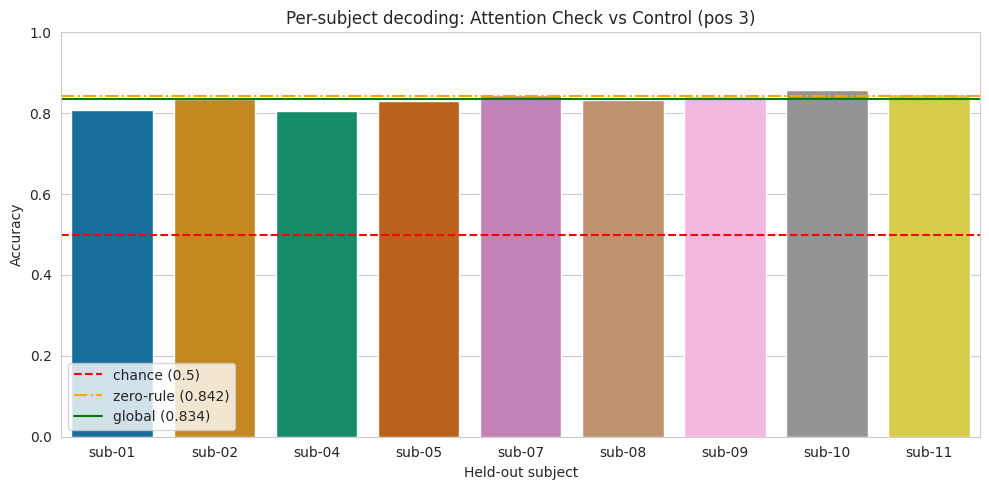

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from copy import deepcopy
from sklearn import metrics
from tqdm import tqdm

N_PERMUTATIONS = 10000
rng = np.random.default_rng(seed=42)


def get_accuracy(df):
    return df[df["prediction"] == df["label"]].shape[0] / df.shape[0]


def get_f1_score(df):
    return metrics.f1_score(df["label"], df["prediction"], average="weighted")


def shuffle_per(df, per_col, shuffle_col, rng):
    df_copy = deepcopy(df)
    for item in set(df[per_col]):
        sub_indices = (df_copy[per_col] == item)
        df_copy.loc[sub_indices, shuffle_col] = rng.permutation(df_copy.loc[sub_indices, shuffle_col])
    return df_copy


accuracy_baseline = get_accuracy(prediction_df)
f1_baseline = get_f1_score(prediction_df)

print(f"Baseline accuracy:  {accuracy_baseline:.4f}")
print(f"Baseline F1 score:  {f1_baseline:.4f}")
print(f"Zero-rule baseline: {zero_rule:.4f}")
print()

if accuracy_baseline <= zero_rule:
    print("WARNING: model accuracy <= zero-rule. Model did not learn beyond majority class.")
print()

larger_acc_count = 0
larger_f1_count = 0

for _ in tqdm(range(N_PERMUTATIONS)):
    shuffled_df = shuffle_per(prediction_df, "subject", "prediction", rng)
    if get_accuracy(shuffled_df) >= accuracy_baseline:
        larger_acc_count += 1
    if get_f1_score(shuffled_df) >= f1_baseline:
        larger_f1_count += 1

p_value_accuracy = larger_acc_count / N_PERMUTATIONS
p_value_f1 = larger_f1_count / N_PERMUTATIONS

print()
print("=" * 50)
print(f"Accuracy p-value: {p_value_accuracy:.4f} ({larger_acc_count}/{N_PERMUTATIONS})")
print(f"F1-score p-value: {p_value_f1:.4f} ({larger_f1_count}/{N_PERMUTATIONS})")
print(f"Zero-rule:        {zero_rule:.4f}")
print(f"Model accuracy:   {accuracy_baseline:.4f}")
print("=" * 50)
if p_value_accuracy < 0.05 and accuracy_baseline > zero_rule:
    print("Significant AND above zero-rule")
elif p_value_accuracy < 0.05:
    print("Significant but AT or BELOW zero-rule (model may just predict majority)")
else:
    print("Not statistically significant")

accuracy_per_subject = prediction_df.groupby("subject").apply(get_accuracy).reset_index()
accuracy_per_subject.columns = ["subject", "accuracy"]

sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=accuracy_per_subject, x="subject", y="accuracy", palette="colorblind")
ax.axhline(0.5, color="red", linestyle="--", label="chance (0.5)")
ax.axhline(zero_rule, color="orange", linestyle="-.", label=f"zero-rule ({zero_rule:.3f})")
ax.axhline(accuracy_baseline, color="green", label=f"global ({accuracy_baseline:.3f})")
ax.set(xlabel="Held-out subject", ylabel="Accuracy", ylim=(0, 1))
ax.legend()
plt.title("Per-subject decoding: Attention Check vs Control (pos 3)")
plt.tight_layout()
plt.show()

#Confidence interval

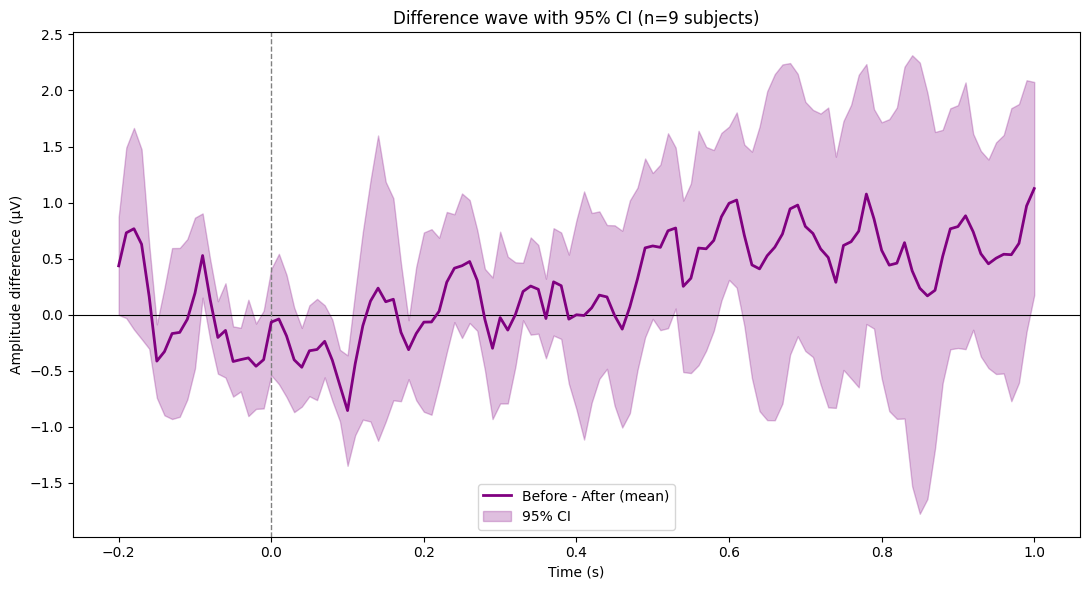

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PICKS = ['Fz', 'CPz', 'Pz']

common_subjs = sorted(set(evokeds_before.keys()) & set(evokeds_after.keys()))

available = evokeds_before[common_subjs[0]].ch_names
pick_idx  = [available.index(ch) for ch in PICKS if ch in available]
times     = evokeds_before[common_subjs[0]].times

diffs = []
for s in common_subjs:
    b = evokeds_before[s].data[pick_idx, :].mean(axis=0)
    a = evokeds_after[s].data[pick_idx, :].mean(axis=0)
    diffs.append((b - a) * 1e6)

diffs = np.array(diffs)
n = len(common_subjs)

mean_diff = diffs.mean(axis=0)
sem = diffs.std(axis=0, ddof=1) / np.sqrt(n)
ci95 = 1.96 * sem

plt.figure(figsize=(11, 6))
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.plot(times, mean_diff, color='purple', linewidth=2, label='Before - After (mean)')
plt.fill_between(times, mean_diff - ci95, mean_diff + ci95,
                 color='purple', alpha=0.25, label='95% CI')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude difference (µV)")
plt.title(f"Difference wave with 95% CI (n={n} subjects)")
plt.legend()
plt.tight_layout()
plt.show()